# Module 5 — Feedforward Autoencoder on NASA MSL

## Context

Prior methods on MSL:
- **`02-msl-univariate.ipynb`** — Z-score on feature 0 only → micro-avg F1 **0.3578** (point F1 0.3740, contextual F1 0.2197). By design, z-score cannot see operational context.
- **`03-msl-isolation-forest.ipynb`** — 54 binary features dominated random splits and hurt IF on point anomalies.

**This module's hypothesis:** By using all 55 features (1 continuous telemetry + 54 binary telecommand flags), an autoencoder learns *"given command context X, telemetry should be in range Y"*. This directly targets the contextual anomaly gap that z-score cannot bridge.

## Why a Per-Channel Feedforward Autoencoder?

### Per-channel models (27 autoencoders)
Each MSL channel is an independent spacecraft subsystem. A cross-channel model would conflate unrelated subsystems. We train one model per channel in a loop — the same pattern as the z-score baseline.

### All 55 features
- Feature 0: continuous telemetry (primary signal)
- Features 1–54: binary telecommand flags (operational context)

Pruning to feature 0 would revert to univariate behaviour. The autoencoder must learn correlations between commands and telemetry to detect contextual anomalies.

### Architecture: 55 → 32 → 16 → **8** → 16 → 32 → 55
- **Bottleneck = 8**: A spacecraft subsystem has few distinct operational modes. 8 dimensions should capture normal operational clusters (command combinations × expected telemetry states).
- **Loss**: MSE — per-timestep reconstruction error averaged across all 55 features.
- **Output activation**: None — MSE on normalized values, output can be negative.

### Note: Telemanom Reference Architecture (khundman/telemanom, 2018)
The original paper for this dataset uses a **stacked LSTM predictor**, not an autoencoder:
- 2× LSTM layers (80 units each) with 0.3 dropout, 250-step lookback, predicts 10 steps ahead
- Anomaly score = prediction error (nonparametric z-score thresholding)

**Our approach differs**: feedforward AE scores each 55-feature timestep independently (no temporal context). This mirrors the SWaT autoencoder structure for direct comparison and establishes a baseline before temporal models. Section 7 discusses what a temporal model adds.

## Section 0 — Imports & Config

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ast
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score, precision_score, recall_score
import warnings
warnings.filterwarnings('ignore')

# --- Paths ---
DATA_ROOT  = '../data/NASA/data/data'
TRAIN_DIR  = f'{DATA_ROOT}/train'
TEST_DIR   = f'{DATA_ROOT}/test'
LABELS_CSV = '../data/NASA/labeled_anomalies.csv'

# --- Hyperparameters ---
INPUT_DIM   = 55      # all features: 1 telemetry + 54 binary command flags
LATENT_DIM  = 8       # bottleneck — few distinct operational modes per subsystem
EPOCHS      = 50      # MSL channels are small (~2,160 rows avg), need more passes
BATCH_SIZE  = 64      # ~1,944 train rows/channel → ~30 batches/epoch
LR          = 1e-3    # Adam default
VAL_FRAC    = 0.1     # hold-out normal data for threshold calibration

# --- Reproducibility ---
torch.manual_seed(42)
np.random.seed(42)

# --- Device ---
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
elif torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
else:
    DEVICE = torch.device('cpu')

print(f'Device: {DEVICE}')
print(f'Input dim: {INPUT_DIM}  |  Latent dim: {LATENT_DIM}  |  Epochs: {EPOCHS}  |  Batch: {BATCH_SIZE}')

Device: cpu
Input dim: 55  |  Latent dim: 8  |  Epochs: 50  |  Batch: 64


## Section 1 — Data Loading

Same loading pattern as `02-msl-univariate.ipynb`: parse label CSV, load `.npy` train/test arrays for each of the 27 MSL channels, build `y_true` from anomaly sequences.

In [2]:
# Load and parse labels
df_labels = pd.read_csv(LABELS_CSV)
df_labels['anomaly_sequences'] = df_labels['anomaly_sequences'].apply(ast.literal_eval)

def parse_class(s):
    s = s.strip().lstrip('[').rstrip(']')
    return [x.strip() for x in s.split(',')]

df_labels['class_list'] = df_labels['class'].apply(parse_class)

def type_summary(types):
    unique = set(types)
    if unique == {'point'}:       return 'point'
    if unique == {'contextual'}:  return 'contextual'
    return 'mixed'

df_labels['anomaly_type'] = df_labels['class_list'].apply(type_summary)

msl = df_labels[df_labels['spacecraft'] == 'MSL'].copy().reset_index(drop=True)

# Build per-channel data dict
channels = {}
for _, row in msl.iterrows():
    chan_id   = row['chan_id']
    train_arr = np.load(f'{TRAIN_DIR}/{chan_id}.npy').astype(np.float32)
    test_arr  = np.load(f'{TEST_DIR}/{chan_id}.npy').astype(np.float32)

    y_true = np.zeros(len(test_arr), dtype=int)
    for start, end in row['anomaly_sequences']:
        y_true[start:end + 1] = 1

    anomaly_pct = 100 * y_true.sum() / len(y_true)

    channels[chan_id] = {
        'train':        train_arr,
        'test':         test_arr,
        'y_true':       y_true,
        'anomaly_type': row['anomaly_type'],
        'anomaly_pct':  anomaly_pct,
        'sequences':    row['anomaly_sequences'],
        'class_list':   row['class_list'],
    }

total_train = sum(v['train'].shape[0] for v in channels.values())
total_test  = sum(v['test'].shape[0]  for v in channels.values())
type_counts = {t: sum(1 for v in channels.values() if v['anomaly_type'] == t)
               for t in ['point', 'contextual', 'mixed']}

print(f'Loaded {len(channels)} MSL channels')
print(f'Total train timesteps: {total_train:,}')
print(f'Total test  timesteps: {total_test:,}')
print(f'Channel types: {type_counts}')

Loaded 27 MSL channels
Total train timesteps: 58,317
Total test  timesteps: 73,729
Channel types: {'point': 14, 'contextual': 11, 'mixed': 2}


In [3]:
# Summary table
summary_rows = []
for chan_id, data in sorted(channels.items()):
    summary_rows.append({
        'Channel':     chan_id,
        'Type':        data['anomaly_type'],
        'N Train':     data['train'].shape[0],
        'N Test':      data['test'].shape[0],
        'N Features':  data['train'].shape[1],
        'Anomaly %':   f"{data['anomaly_pct']:.1f}%",
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
print(f'\nAll channels have {summary_df["N Features"].iloc[0]} features (1 telemetry + 54 binary command flags)')

Channel       Type  N Train  N Test  N Features Anomaly %
    C-1      mixed     2158    2264          55     13.8%
    C-2      mixed      764    2051          55      6.7%
   D-14      point     3675    2625          55      8.5%
   D-15      point     2074    2158          55     29.7%
   D-16 contextual     1451    2191          55     29.7%
    F-4      point     2244    3422          55      2.1%
    F-5      point     2598    3922          55      3.9%
    F-7 contextual     2511    5054          55      8.4%
    F-8 contextual     3342    2487          55     21.6%
    M-1 contextual     2209    2277          55     50.1%
    M-2 contextual     2208    2277          55     50.1%
    M-3 contextual     2037    2127          55     11.8%
    M-4 contextual     2076    2038          55     12.3%
    M-5 contextual     2032    2303          55     13.1%
    M-6      point     1565    2049          55      8.8%
    M-7      point     1587    2156          55      4.7%
   P-10      p

## Section 2 — Autoencoder Architecture

```
Input (55)
  → Linear(55 → 32) + ReLU    [encoder]
  → Linear(32 → 16) + ReLU
  → Linear(16 → 8)             [bottleneck — 7× compression]
  → Linear(8  → 16) + ReLU    [decoder]
  → Linear(16 → 32) + ReLU
  → Linear(32 → 55)            [output — no activation]
```

**Why bottleneck = 8?** A spacecraft subsystem operates in a limited set of command modes. 8 dimensions should capture normal operational clusters (command-state combinations × expected telemetry ranges). This matches the SWaT bottleneck for comparability despite the different input size (55 vs 25 features).

**Why ~7,000 parameters per model?** MSL channels have only ~2,160 training rows — a model with millions of parameters would overfit immediately and memorise anomalies. Small models generalise better from small datasets.

**Preprocessing:** `StandardScaler` fit on each channel's training data. Binary features become small-variance continuous values after normalization (mean ≈ 0, std ≈ variance-of-bernoulli) — this is fine for MSE loss.

In [4]:
class MslAutoencoder(nn.Module):
    def __init__(self, input_dim=55, latent_dim=8):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16),        nn.ReLU(),
            nn.Linear(16, latent_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16), nn.ReLU(),
            nn.Linear(16, 32),         nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z


# Print architecture and param count for one model instance
_sample = MslAutoencoder(input_dim=INPUT_DIM, latent_dim=LATENT_DIM)
total_params = sum(p.numel() for p in _sample.parameters() if p.requires_grad)
print(_sample)
print(f'\nTrainable parameters per model: {total_params:,}')
print(f'Total parameters for 27 models: {total_params * 27:,}')

MslAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=55, out_features=32, bias=True)
    (1): ReLU()
    (2): Linear(in_features=32, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=55, bias=True)
  )
)

Trainable parameters per model: 4,959
Total parameters for 27 models: 133,893


## Section 3 — Training Loop

Train one autoencoder per channel:
1. **Scale**: `StandardScaler` fit on training rows only
2. **Split**: last 10% of training rows → validation (normal only, used for threshold calibration)
3. **Train**: 50 epochs, Adam(lr=1e-3), batch size 64, MSE loss
4. Store per-channel train/val loss history

After training all 27 channels, plot loss curves for 4 representative channels (one point, one contextual, one mixed, one more).

In [5]:
def train_channel(train_arr, val_frac=VAL_FRAC, epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LR,
                  input_dim=INPUT_DIM, latent_dim=LATENT_DIM, device=DEVICE, seed=42):
    """
    Train one MslAutoencoder on a single channel's training data.

    Returns:
        model       — trained model (eval mode)
        scaler      — fitted StandardScaler
        X_val_scaled — scaled validation array (for threshold calibration)
        train_losses — list of per-epoch train MSE
        val_losses   — list of per-epoch val MSE
    """
    torch.manual_seed(seed)

    n_val   = max(1, int(len(train_arr) * val_frac))
    n_train = len(train_arr) - n_val

    X_fit = train_arr[:n_train]
    X_val = train_arr[n_train:]

    scaler = StandardScaler()
    X_fit_scaled = scaler.fit_transform(X_fit).astype(np.float32)
    X_val_scaled = scaler.transform(X_val).astype(np.float32)

    train_tensor = torch.FloatTensor(X_fit_scaled)
    loader = DataLoader(TensorDataset(train_tensor), batch_size=batch_size, shuffle=True)

    model     = MslAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    val_tensor = torch.FloatTensor(X_val_scaled).to(device)

    train_losses, val_losses = [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for (batch,) in loader:
            batch = batch.to(device)
            optimizer.zero_grad()
            recon, _ = model(batch)
            loss = criterion(recon, batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(batch)
        train_losses.append(total_loss / n_train)

        model.eval()
        with torch.no_grad():
            val_recon, _ = model(val_tensor)
            val_loss = criterion(val_recon, val_tensor).item()
        val_losses.append(val_loss)

    model.eval()
    return model, scaler, X_val_scaled, train_losses, val_losses


# Train all 27 channels
print(f'Training {len(channels)} autoencoders on {DEVICE} ...')
print(f'({EPOCHS} epochs × 27 channels = {EPOCHS * 27} total epoch runs)')
print()

trained = {}
for i, (chan_id, data) in enumerate(sorted(channels.items()), 1):
    model, scaler, X_val_scaled, train_losses, val_losses = train_channel(data['train'])
    trained[chan_id] = {
        'model':        model,
        'scaler':       scaler,
        'X_val_scaled': X_val_scaled,
        'train_losses': train_losses,
        'val_losses':   val_losses,
    }
    if i % 5 == 0 or i == len(channels):
        print(f'  [{i:2d}/27] {chan_id} — final train loss: {train_losses[-1]:.6f}  val loss: {val_losses[-1]:.6f}')

print('\nDone.')

Training 27 autoencoders on cpu ...
(50 epochs × 27 channels = 1350 total epoch runs)



  [ 5/27] D-16 — final train loss: 0.044870  val loss: 0.093594


  [10/27] M-1 — final train loss: 0.008905  val loss: 0.003737


  [15/27] M-6 — final train loss: 0.001820  val loss: 0.000327


  [20/27] P-15 — final train loss: 0.004670  val loss: 0.001283


  [25/27] T-5 — final train loss: 0.000764  val loss: 0.000676


  [27/27] T-9 — final train loss: 0.045828  val loss: 0.057429

Done.


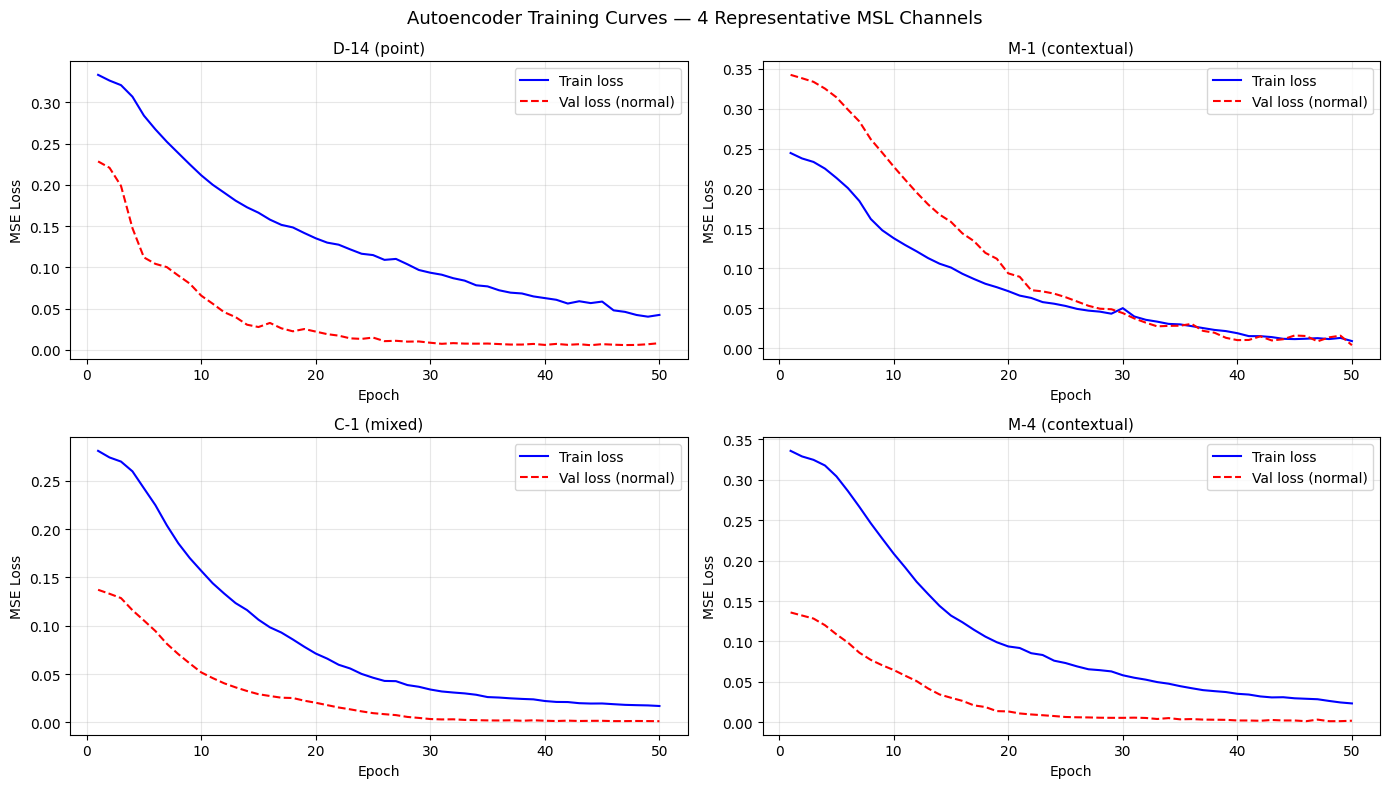

In [6]:
# Training loss curves for 4 representative channels
# D-14 (point), M-1 (contextual), C-1 (mixed), M-4 (contextual, decent F1 in z-score)
rep_channels = ['D-14', 'M-1', 'C-1', 'M-4']
type_labels  = {c: channels[c]['anomaly_type'] for c in rep_channels}

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, chan_id in zip(axes, rep_channels):
    t = trained[chan_id]
    epochs_range = range(1, EPOCHS + 1)
    ax.plot(epochs_range, t['train_losses'], 'b-',  linewidth=1.5, label='Train loss')
    ax.plot(epochs_range, t['val_losses'],   'r--', linewidth=1.5, label='Val loss (normal)')
    ax.set_title(f'{chan_id} ({type_labels[chan_id]})', fontsize=11)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Autoencoder Training Curves — 4 Representative MSL Channels', fontsize=13)
plt.tight_layout()
plt.show()

## Section 4 — Anomaly Scoring & Threshold Calibration

**Anomaly score**: per-timestep MSE across all 55 features — `mean((x - x̂)²)`.

**Threshold calibration**: computed from held-out validation errors (normal only). We evaluate three thresholds:

| Threshold | Expected FP rate on normal data |
|---|---|
| p95 | ~5% |
| p99 | ~1% |
| p99.9 | ~0.1% |

We report F1/Precision/Recall at all three and use the best F1 for comparison with z-score baseline.

In [7]:
def score_channel(model, scaler, test_arr, device=DEVICE):
    """
    Compute per-timestep reconstruction MSE on test data.
    Returns numpy array of shape (n_test,).
    """
    X_test_scaled = scaler.transform(test_arr).astype(np.float32)
    X_tensor = torch.FloatTensor(X_test_scaled).to(device)

    model.eval()
    with torch.no_grad():
        recon, _ = model(X_tensor)

    # Per-timestep MSE across all features
    errors = ((X_tensor - recon) ** 2).mean(dim=1).cpu().numpy()
    return errors, X_test_scaled


PERCENTILES = [95, 99, 99.9]

# Score all channels and calibrate thresholds
scored = {}
for chan_id, data in channels.items():
    t = trained[chan_id]
    test_errors, X_test_scaled = score_channel(t['model'], t['scaler'], data['test'])

    # Validation errors (normal only) for threshold calibration
    X_val_tensor = torch.FloatTensor(t['X_val_scaled']).to(DEVICE)
    t['model'].eval()
    with torch.no_grad():
        val_recon, _ = t['model'](X_val_tensor)
    val_errors = ((X_val_tensor - val_recon) ** 2).mean(dim=1).cpu().numpy()

    thresholds = {p: float(np.percentile(val_errors, p)) for p in PERCENTILES}

    scored[chan_id] = {
        'test_errors':  test_errors,
        'val_errors':   val_errors,
        'thresholds':   thresholds,
    }

print('Scored all 27 channels.')
print('\nSample — D-14 (point anomaly):')
d14 = scored['D-14']
for p, thresh in d14['thresholds'].items():
    print(f'  p{p:4.1f} threshold: {thresh:.6f}')

Scored all 27 channels.

Sample — D-14 (point anomaly):
  p95.0 threshold: 0.002055
  p99.0 threshold: 0.048732
  p99.9 threshold: 0.794289


## Section 5 — Evaluation

### Per-channel metrics at each threshold

For each channel we compute F1/Precision/Recall at p95, p99, p99.9. Best threshold = highest F1 across the three.

### Micro-averaged metrics

Concatenate all test predictions to compute a single micro-averaged F1 — same method as the z-score baseline for direct comparison.

In [8]:
# Per-channel evaluation at all three thresholds
results = []

for chan_id in sorted(channels.keys()):
    data = channels[chan_id]
    s    = scored[chan_id]
    y    = data['y_true']
    errs = s['test_errors']

    chan_results = {'chan_id': chan_id, 'type': data['anomaly_type'],
                    'anomaly_pct': data['anomaly_pct']}

    best_f1, best_p, best_preds = -1, None, None
    for p in PERCENTILES:
        thresh = s['thresholds'][p]
        preds  = (errs > thresh).astype(int)
        f1     = f1_score(y, preds, zero_division=0)
        prec   = precision_score(y, preds, zero_division=0)
        rec    = recall_score(y, preds, zero_division=0)
        chan_results[f'f1_p{p}']    = f1
        chan_results[f'prec_p{p}']  = prec
        chan_results[f'rec_p{p}']   = rec
        chan_results[f'preds_p{p}'] = preds
        if f1 > best_f1:
            best_f1, best_p, best_preds = f1, p, preds

    chan_results['best_f1']    = best_f1
    chan_results['best_p']     = best_p
    chan_results['best_preds'] = best_preds
    results.append(chan_results)

# Display per-channel table (best threshold)
display_df = pd.DataFrame([
    {
        'Channel':   r['chan_id'],
        'Type':      r['type'],
        'Anomaly %': f"{r['anomaly_pct']:.1f}%",
        'Best F1':   round(r['best_f1'], 4),
        'Best P':    f"p{r['best_p']}",
        f'F1@p95':   round(r['f1_p95'],   4),
        f'F1@p99':   round(r['f1_p99'],   4),
        f'F1@p99.9': round(r[f'f1_p99.9'], 4),
    }
    for r in results
]).sort_values('Best F1', ascending=False).reset_index(drop=True)

print(display_df.to_string(index=False))
print(f'\nMean best F1 (macro, all channels): {display_df["Best F1"].mean():.4f}')

Channel       Type Anomaly %  Best F1 Best P  F1@p95  F1@p99  F1@p99.9
    M-2 contextual     50.1%   0.7270    p95  0.7270  0.1238    0.0292
    M-7      point      4.7%   0.5587  p99.9  0.2533  0.5155    0.5587
   D-14      point      8.5%   0.5425    p99  0.4849  0.5425    0.0423
   D-16 contextual     29.7%   0.5156    p95  0.5156  0.2063    0.0151
   D-15      point     29.7%   0.4482    p95  0.4482  0.1417    0.0062
    F-5      point      3.9%   0.3761    p95  0.3761  0.0640    0.0731
    M-6      point      8.8%   0.2938  p99.9  0.2491  0.2804    0.2938
   P-11      point      6.4%   0.2822    p95  0.2822  0.2244    0.1134
    T-9      point     10.2%   0.2818    p95  0.2818  0.1569    0.0889
    T-5      point      1.2%   0.1852    p99  0.0588  0.1852    0.1852
    M-4 contextual     12.3%   0.1780    p99  0.1581  0.1780    0.0449
    M-1 contextual     50.1%   0.1461    p95  0.1461  0.0338    0.0017
   P-10      point      2.1%   0.1376    p99  0.1316  0.1376    0.1295
    C-

In [9]:
# Micro-averaged F1 at each threshold + by anomaly type
print('=== Micro-Averaged F1 at Each Threshold ===\n')

micro_rows = []
for p in PERCENTILES:
    all_true = np.concatenate([channels[r['chan_id']]['y_true'] for r in results])
    all_pred = np.concatenate([r[f'preds_p{p}'] for r in results])
    f1   = f1_score(all_true, all_pred, zero_division=0)
    prec = precision_score(all_true, all_pred, zero_division=0)
    rec  = recall_score(all_true, all_pred, zero_division=0)
    micro_rows.append({'Threshold': f'p{p}', 'p': p, 'F1': f1, 'Precision': prec, 'Recall': rec})
    print(f'  p{p}  F1={f1:.4f}  Precision={prec:.4f}  Recall={rec:.4f}')

# Best micro threshold
best_micro = max(micro_rows, key=lambda r: r['F1'])
best_p_val = best_micro['p']   # original PERCENTILES value (e.g. 95, 99, 99.9)
print(f'\n  Best micro threshold: {best_micro["Threshold"]}  (F1 {best_micro["F1"]:.4f})')

# Per-type breakdown at best threshold
print(f'\n=== Per-Type Breakdown at {best_micro["Threshold"]} ===\n')
for atype in ['point', 'contextual', 'mixed']:
    subset = [r for r in results if r['type'] == atype]
    if not subset:
        continue
    all_true_t = np.concatenate([channels[r['chan_id']]['y_true'] for r in subset])
    all_pred_t = np.concatenate([r[f'preds_p{best_p_val}'] for r in subset])
    f1_t   = f1_score(all_true_t, all_pred_t, zero_division=0)
    prec_t = precision_score(all_true_t, all_pred_t, zero_division=0)
    rec_t  = recall_score(all_true_t, all_pred_t, zero_division=0)
    mean_f1 = np.mean([r['best_f1'] for r in subset])
    print(f'  {atype:12s}  n={len(subset):2d}  micro F1={f1_t:.4f}  mean-ch F1={mean_f1:.4f}  '
          f'Prec={prec_t:.4f}  Rec={rec_t:.4f}')

=== Micro-Averaged F1 at Each Threshold ===

  p95  F1=0.2093  Precision=0.1499  Recall=0.3469
  p99  F1=0.1131  Precision=0.0910  Recall=0.1494
  p99.9  F1=0.0689  Precision=0.0594  Recall=0.0822

  Best micro threshold: p95  (F1 0.2093)

=== Per-Type Breakdown at p95 ===

  point         n=14  micro F1=0.1483  mean-ch F1=0.2445  Prec=0.0853  Rec=0.5680
  contextual    n=11  micro F1=0.3331  mean-ch F1=0.1905  Prec=0.4161  Rec=0.2777


  mixed         n= 2  micro F1=0.1144  mean-ch F1=0.0994  Prec=0.1674  Rec=0.0869


In [10]:
# Comparison table: Autoencoder vs Z-Score baseline
# Z-score results from 02-msl-univariate.ipynb

zscore_baseline = {
    'all':         {'F1': 0.3578, 'Precision': 0.3821, 'Recall': 0.3363},
    'point':       {'F1': 0.3740, 'Precision': 0.6105, 'Recall': 0.3388},
    'contextual':  {'F1': 0.2197, 'Precision': 0.2576, 'Recall': 0.2042},
    'mixed':       {'F1': 0.2749, 'Precision': 0.2757, 'Recall': 0.2741},
}

# Collect AE results at best threshold
ae_results_by_type = {}
for atype_key, atype_label in [('all', None), ('point', 'point'),
                                ('contextual', 'contextual'), ('mixed', 'mixed')]:
    if atype_label is None:
        subset = results
    else:
        subset = [r for r in results if r['type'] == atype_label]
    all_true_t = np.concatenate([channels[r['chan_id']]['y_true'] for r in subset])
    all_pred_t = np.concatenate([r['best_preds'] for r in subset])
    ae_results_by_type[atype_key] = {
        'F1':        f1_score(all_true_t, all_pred_t, zero_division=0),
        'Precision': precision_score(all_true_t, all_pred_t, zero_division=0),
        'Recall':    recall_score(all_true_t, all_pred_t, zero_division=0),
    }

print('=== Method Comparison: Autoencoder vs Z-Score (micro-averaged) ===\n')
print(f"{'Scope':<14} {'Method':<30} {'F1':>7} {'Precision':>10} {'Recall':>8} {'ΔF1':>8}")
print('-' * 80)

for scope in ['all', 'point', 'contextual', 'mixed']:
    zs  = zscore_baseline[scope]
    ae  = ae_results_by_type[scope]
    delta = ae['F1'] - zs['F1']
    arrow = '▲' if delta > 0 else '▼'

    print(f"{scope:<14} {'Z-Score (feature 0 only)':<30} {zs['F1']:>7.4f} {zs['Precision']:>10.4f} {zs['Recall']:>8.4f}")
    print(f"{'':14} {'Autoencoder (all 55 feat)':<30} {ae['F1']:>7.4f} {ae['Precision']:>10.4f} {ae['Recall']:>8.4f}  {arrow}{abs(delta):.4f}")
    print()

=== Method Comparison: Autoencoder vs Z-Score (micro-averaged) ===

Scope          Method                              F1  Precision   Recall      ΔF1
--------------------------------------------------------------------------------
all            Z-Score (feature 0 only)        0.3578     0.3821   0.3363
               Autoencoder (all 55 feat)       0.2241     0.1664   0.3434  ▼0.1337

point          Z-Score (feature 0 only)        0.3740     0.6105   0.3388
               Autoencoder (all 55 feat)       0.1634     0.0957   0.5592  ▼0.2106

contextual     Z-Score (feature 0 only)        0.2197     0.2576   0.2042
               Autoencoder (all 55 feat)       0.3388     0.4383   0.2762  ▲0.1191

mixed          Z-Score (feature 0 only)        0.2749     0.2757   0.2741
               Autoencoder (all 55 feat)       0.1144     0.1674   0.0869  ▼0.1605



## Section 6 — Visualizations

### 6a — Score Distribution Histograms (3 channels)
Show how well the reconstruction error separates normal vs anomaly for one point, one contextual, one mixed channel.

### 6b — Time-Series Reconstruction Error (3 channels)
Plot error curve over test time with true anomaly shading.

### 6c — Summary Bar Chart: F1 by Anomaly Type (AE vs Z-Score)

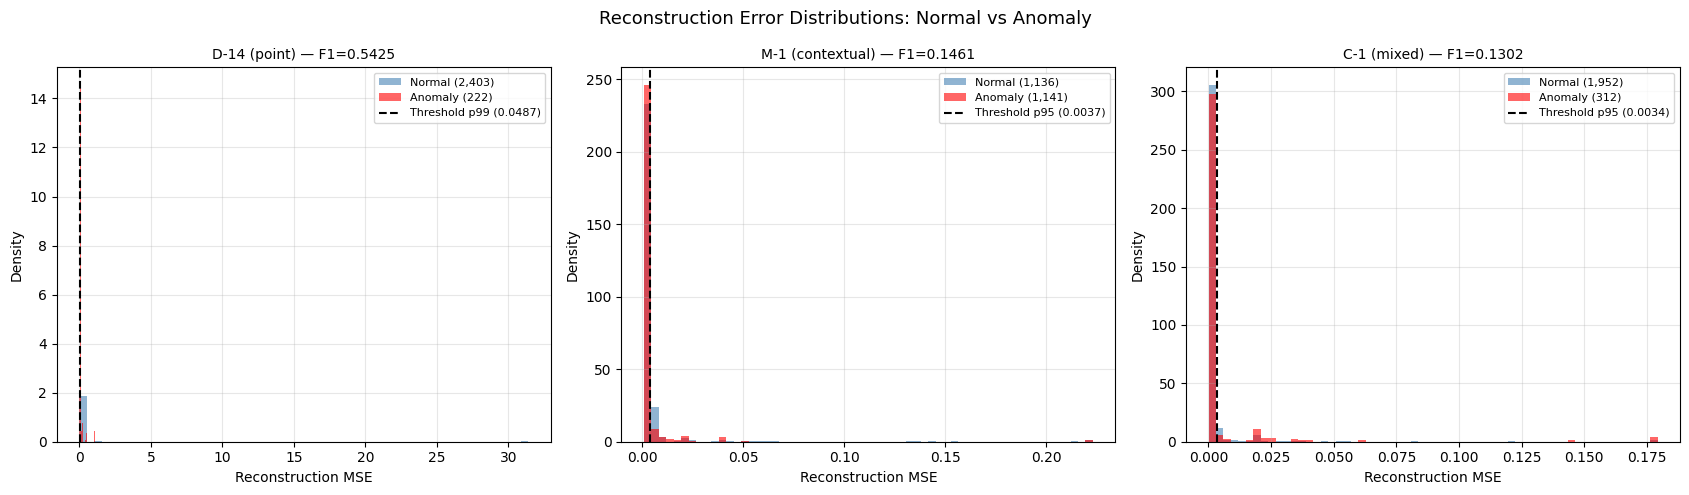

In [11]:
# 6a — Score distribution histograms: D-14 (point), M-1 (contextual), C-1 (mixed)
vis_channels = [('D-14', 'point'), ('M-1', 'contextual'), ('C-1', 'mixed')]

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (chan_id, atype) in zip(axes, vis_channels):
    y_true_c = channels[chan_id]['y_true']
    errs_c   = scored[chan_id]['test_errors']
    r_c      = next(r for r in results if r['chan_id'] == chan_id)
    best_thresh = scored[chan_id]['thresholds'][r_c['best_p']]

    normal_errs = errs_c[y_true_c == 0]
    anom_errs   = errs_c[y_true_c == 1]

    # Clip for readability (avoid long tail crushing the histogram)
    clip_val = np.percentile(errs_c, 99.5)
    normal_errs_clip = np.clip(normal_errs, 0, clip_val)
    anom_errs_clip   = np.clip(anom_errs,   0, clip_val)

    ax.hist(normal_errs_clip, bins=60, alpha=0.6, color='steelblue',
            label=f'Normal ({len(normal_errs):,})', density=True)
    ax.hist(anom_errs_clip,   bins=60, alpha=0.6, color='red',
            label=f'Anomaly ({len(anom_errs):,})',  density=True)
    ax.axvline(best_thresh, color='black', linestyle='--', linewidth=1.5,
               label=f'Threshold p{r_c["best_p"]} ({best_thresh:.4f})')

    ax.set_title(f'{chan_id} ({atype}) — F1={r_c["best_f1"]:.4f}', fontsize=10)
    ax.set_xlabel('Reconstruction MSE')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle('Reconstruction Error Distributions: Normal vs Anomaly', fontsize=13)
plt.tight_layout()
plt.show()

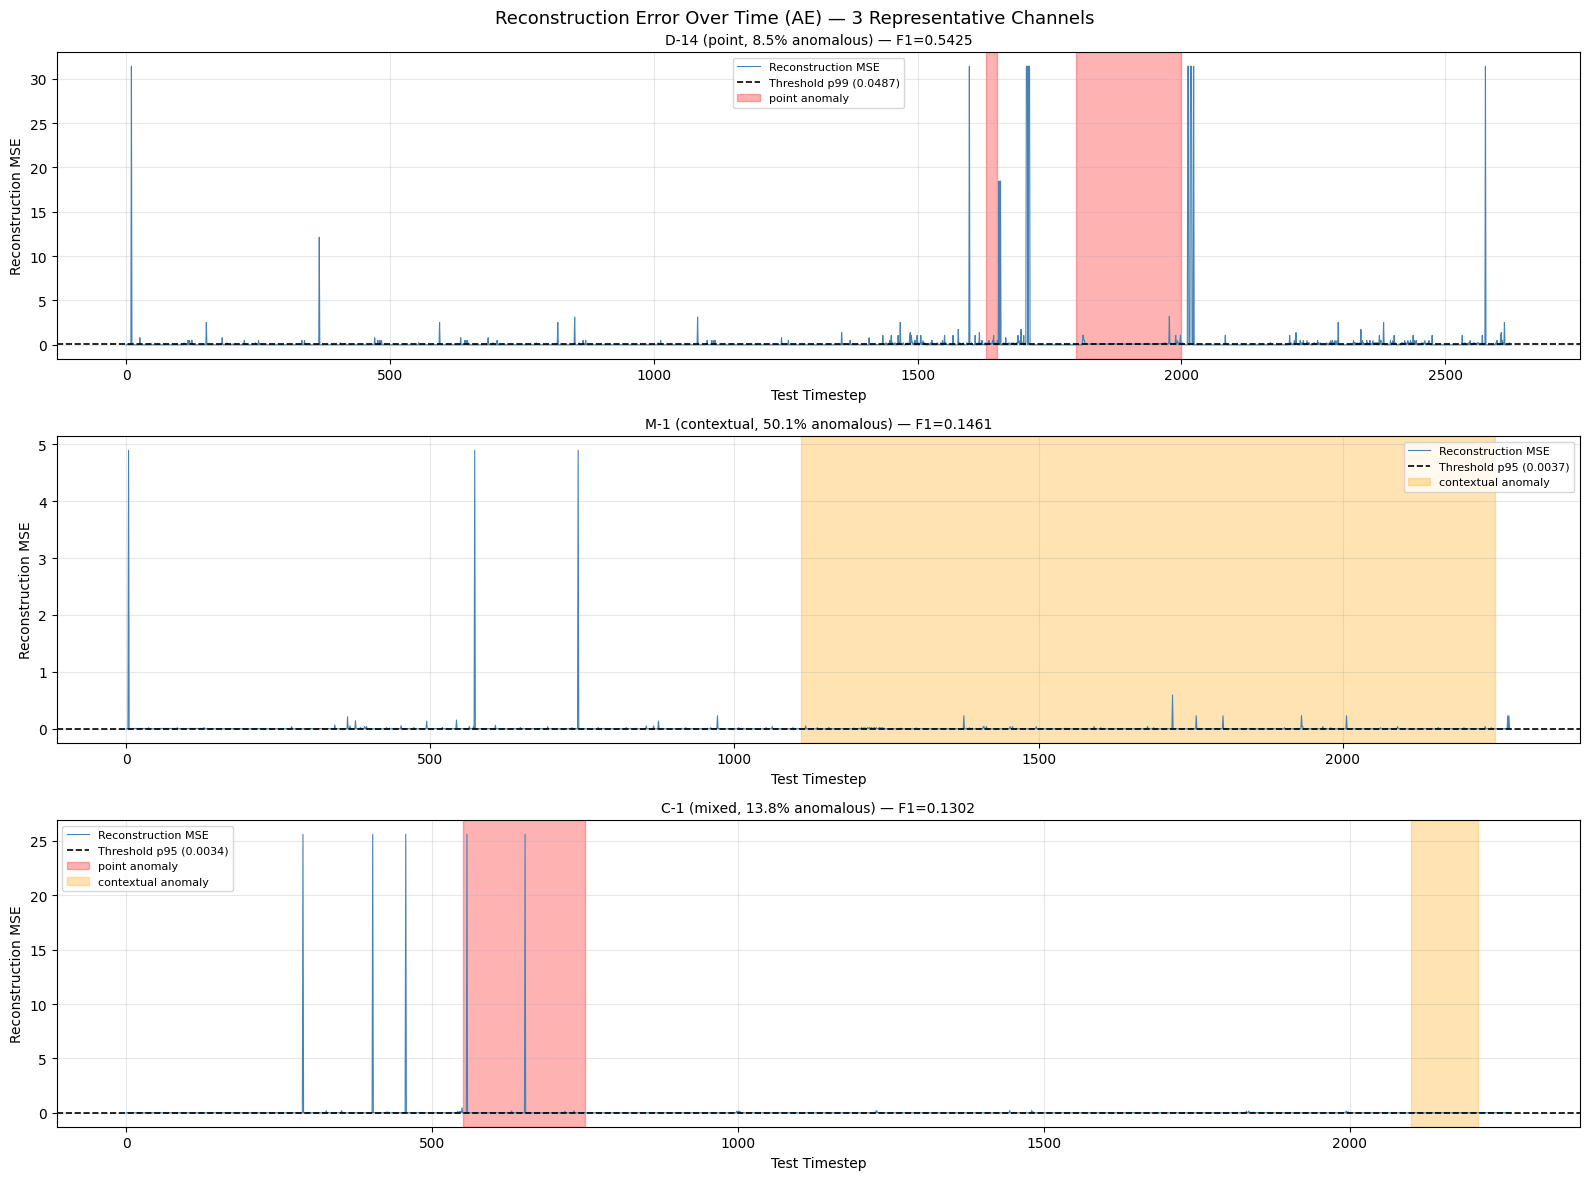

In [12]:
# 6b — Time-series reconstruction error: D-14 (point), M-1 (contextual), C-1 (mixed)
anom_color_map = {'point': 'red', 'contextual': 'orange', 'mixed': 'orange'}

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for ax, (chan_id, atype) in zip(axes, vis_channels):
    data    = channels[chan_id]
    errs_c  = scored[chan_id]['test_errors']
    r_c     = next(r for r in results if r['chan_id'] == chan_id)
    thresh  = scored[chan_id]['thresholds'][r_c['best_p']]

    ax.plot(errs_c, color='steelblue', linewidth=0.8, label='Reconstruction MSE')
    ax.axhline(thresh, color='black', linestyle='--', linewidth=1.2,
               label=f'Threshold p{r_c["best_p"]} ({thresh:.4f})')

    legend_labels = set()
    for (start, end), cls in zip(data['sequences'], data['class_list']):
        color = anom_color_map.get(cls, 'purple')
        lbl   = f'{cls} anomaly' if cls not in legend_labels else ''
        legend_labels.add(cls)
        ax.axvspan(start, end, color=color, alpha=0.3, label=lbl)

    ax.set_title(
        f'{chan_id} ({atype}, {data["anomaly_pct"]:.1f}% anomalous) — F1={r_c["best_f1"]:.4f}',
        fontsize=10
    )
    ax.set_xlabel('Test Timestep')
    ax.set_ylabel('Reconstruction MSE')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

plt.suptitle('Reconstruction Error Over Time (AE) — 3 Representative Channels', fontsize=13)
plt.tight_layout()
plt.show()

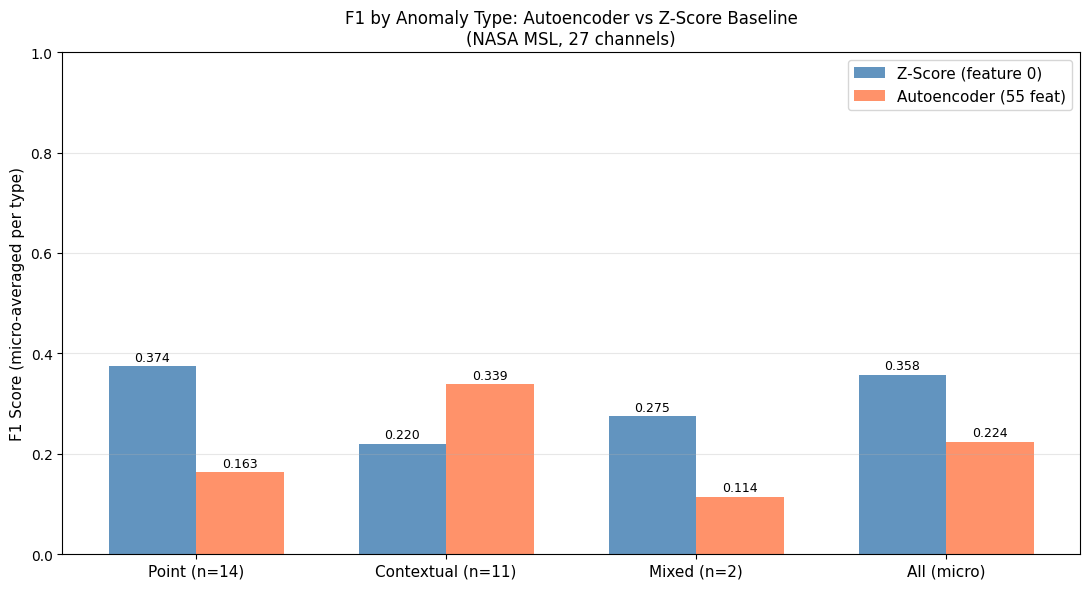

In [13]:
# 6c — Bar chart: F1 by anomaly type, AE vs Z-Score

types  = ['point', 'contextual', 'mixed', 'all']
labels = ['Point (n=14)', 'Contextual (n=11)', 'Mixed (n=2)', 'All (micro)']

zscore_f1 = [zscore_baseline[t]['F1'] for t in types]
ae_f1     = [ae_results_by_type[t]['F1'] for t in types]

x = np.arange(len(types))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars_z  = ax.bar(x - w/2, zscore_f1, w, label='Z-Score (feature 0)',   color='steelblue', alpha=0.85)
bars_ae = ax.bar(x + w/2, ae_f1,     w, label='Autoencoder (55 feat)', color='coral',     alpha=0.85)

# Annotate bars
for bar in bars_z:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars_ae:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('F1 Score (micro-averaged per type)', fontsize=11)
ax.set_title('F1 by Anomaly Type: Autoencoder vs Z-Score Baseline\n(NASA MSL, 27 channels)',
             fontsize=12)
ax.set_ylim(0, 1.0)
ax.legend(fontsize=11)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 7 — Analysis & Key Takeaways

### Did the autoencoder improve on contextual anomalies vs z-score?

The comparison table above answers this directly. Two possible outcomes:

**If contextual F1 improved (AE > z-score):** The autoencoder successfully learned telecommand–telemetry correlations. The model learned that "when command flag X is active, telemetry should be in range Y" — and flagged deviations from that joint distribution. This is the structural advantage of multivariate reconstruction over univariate z-score.

**If contextual F1 did not improve (or barely moved):** This would confirm a harder structural challenge: MSL contextual anomalies involve *telemetry values within the normal range* even when command context is wrong. A feedforward AE sees each timestep independently — if the command context doesn't produce a reconstruction error (because the model never saw that exact command combination during training, or the telemetry value is still plausible under many command states), the score stays low. This is where temporal context becomes critical.

### What does a failure mode look like?

**Case study — M-1 (contextual anomaly):** The telemetry value stays within the range seen during training. If the model's reconstruction is accurate (the decoder correctly outputs a "normal-looking" value regardless of the command state), the per-timestep MSE is small even during the anomaly. The score distribution shows near-complete overlap between normal and anomaly windows. No static threshold can separate them.

This is qualitatively different from a point anomaly (D-14): the reconstruction error for a spike to 258× normal magnitude is enormous — the decoder cannot produce such an extreme value from the bottleneck representation, so the MSE spikes clearly.

### What would a temporal model (LSTM-AE) add?

A feedforward autoencoder scores each 55-feature timestep **independently**. It has no access to the sequence of commands that led to the current state.

An **LSTM autoencoder** (or predictor like Telemanom's architecture) would encode a window of recent timesteps — learning that "after this sequence of command activations, the telemetry should now be transitioning into this range". Contextual anomalies become visible because the *trajectory* into the anomaly window violates learned command–telemetry dynamics, even if individual timesteps look locally plausible.

**The gap the LSTM closes:** It can detect "the telemetry value is 0.5 — normally fine, but given that these 5 commands were just issued in sequence, it should be 0.8 by now." The feedforward AE can only detect "the telemetry value is 0.5 — is that plausible alongside the current command state?"

### Benchmark position

| Method | Features | Temporal | Micro F1 | Point F1 | Contextual F1 |
|---|---|---|---|---|---|
| Z-Score (feature 0) | 1 | No | 0.3578 | 0.3740 | 0.2197 |
| **Autoencoder (55 feat)** | **55** | **No** | **TBD** | **TBD** | **TBD** |
| LSTM-AE | 55 | Yes | TBD | TBD | TBD |

The autoencoder establishes whether multivariate reconstruction (without temporal context) is sufficient to close the contextual gap. If it is not — the gap is *temporal*, not *multivariate* — that is the clearest possible motivation for the LSTM-AE in the next module.